<a href="https://colab.research.google.com/github/aryan28105/Book-Buddy/blob/main/Corona_Discharge_(2).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ── Step 1 : Install & Import ──────────────────────────────────────────────
!pip install pandas numpy scikit-learn matplotlib seaborn -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, classification_report,
                              confusion_matrix, precision_recall_fscore_support)
import warnings
warnings.filterwarnings('ignore')

# ── Global plot style ───────────────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams.update({
    'figure.dpi': 130,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.family': 'DejaVu Sans',
})

PALETTE   = ['#4C72B0','#DD8452','#55A868','#C44E52']
HC_COLORS = ['#2ecc71','#27ae60','#f39c12','#e67e22','#e74c3c']   # HC1→HC5
MODEL_NAMES = ['Logistic Regression','Random Forest','Gradient Boosting','SVM']
print('✓ Libraries ready')


✓ Libraries ready


In [ ]:
# ── Step 2 : Upload & Load Dataset ─────────────────────────────────────────
from google.colab import files
uploaded = files.upload()
csv_path = list(uploaded.keys())[0]

df = pd.read_csv(csv_path)
print(f'Dataset shape : {df.shape}')
print(f'Columns       : {list(df.columns)}')
print()
print('HC_class distribution:')
print(df['HC_class'].value_counts().sort_index())


Saving hydrophobicity_corona_dataset.csv to hydrophobicity_corona_dataset.csv
Dataset shape : (76, 17)
Columns       : ['sample_id', 'material', 'filler', 'filler_phr', 'voltage_kV', 'frequency_Hz', 'gap_mm', 'exposure_h', 'cycle_no', 'phase', 'humidity_pct', 'temp_C', 'contamination', 'contact_angle_deg', 'HC_class', 'source', 'notes']

HC_class distribution:
HC_class
1    18
2    26
3    17
4    11
5     3
6     1
Name: count, dtype: int64


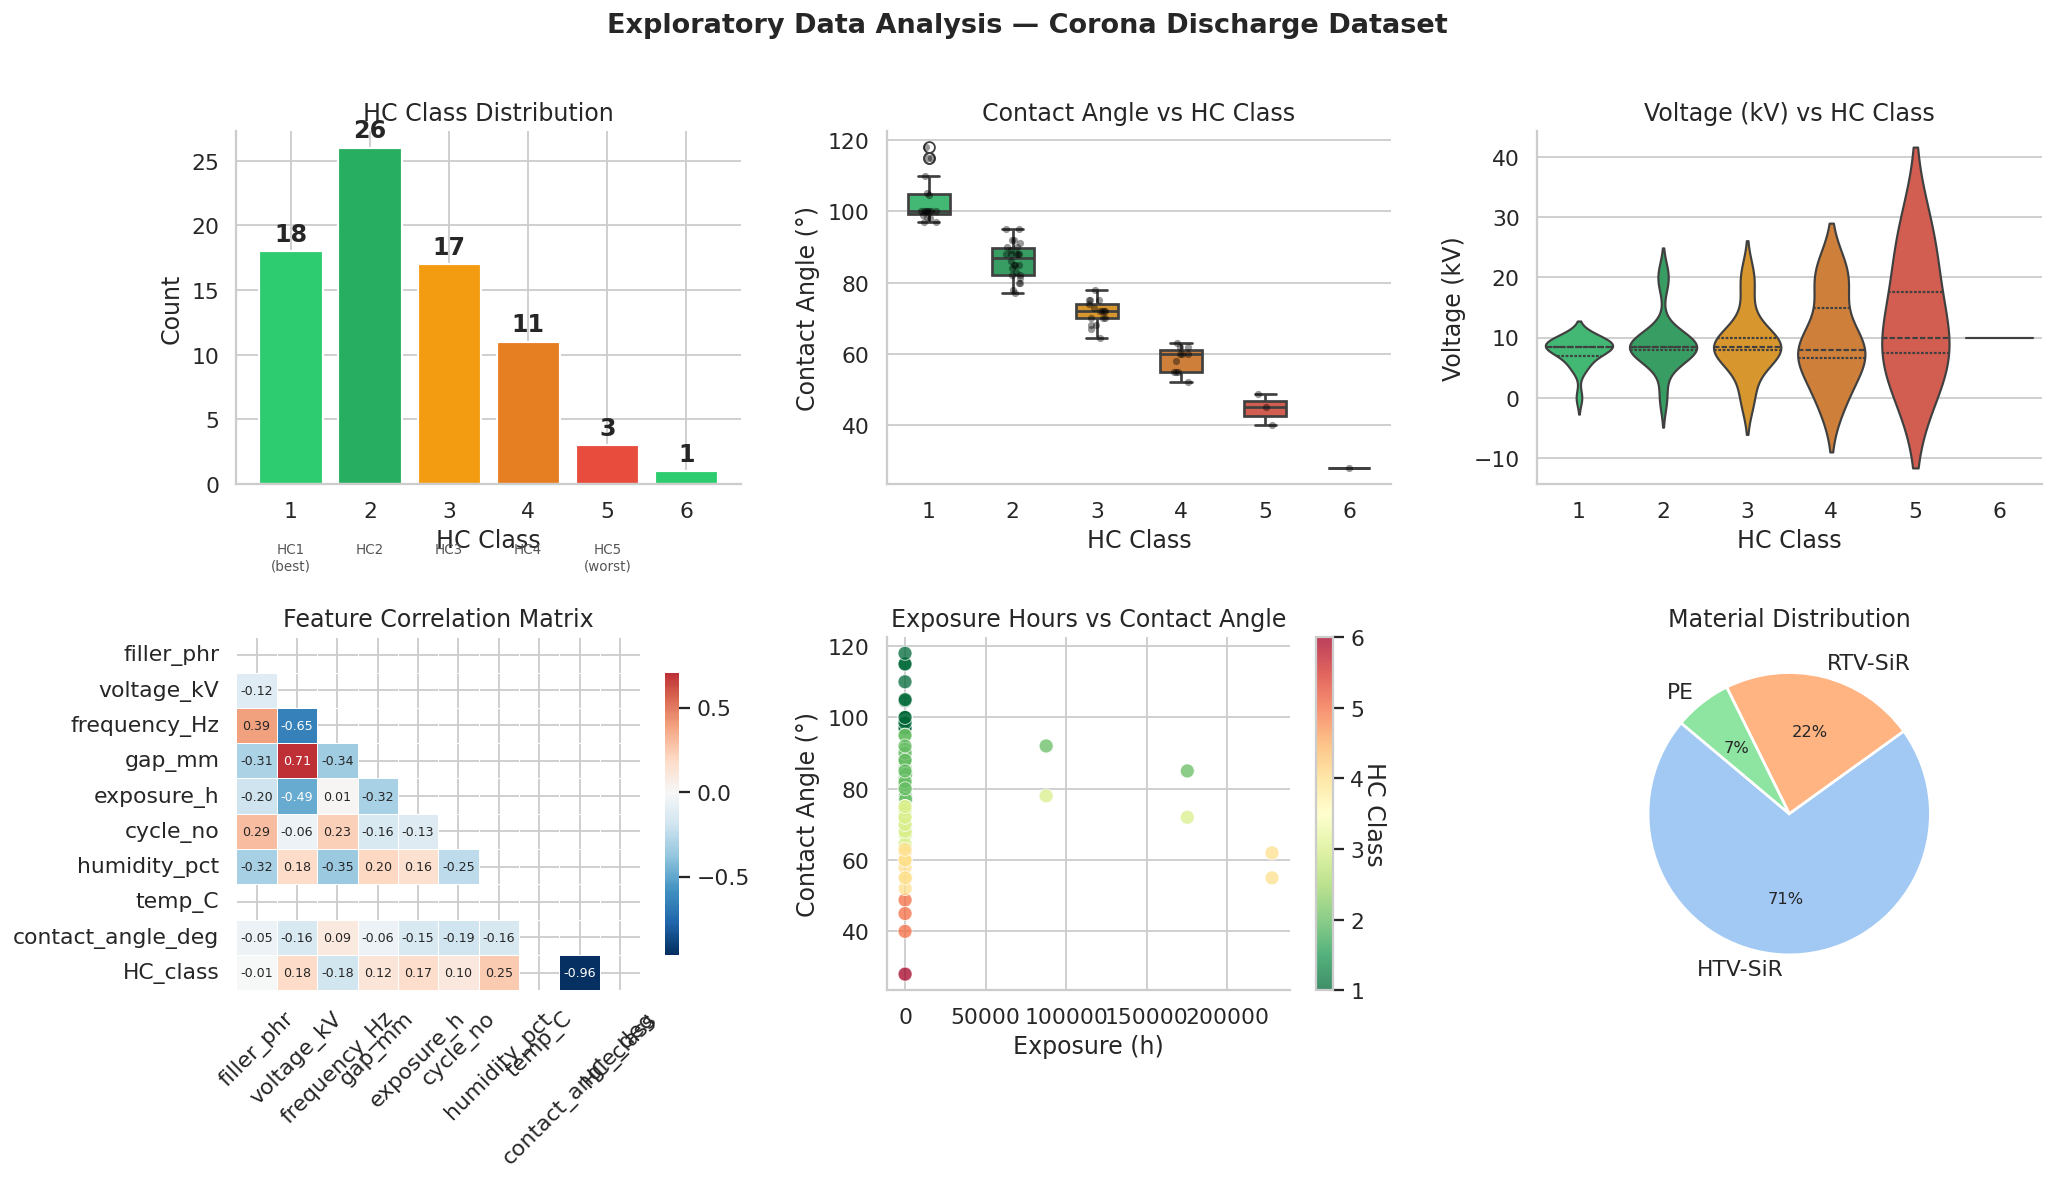

✓ EDA plots saved → eda_overview.png


In [ ]:
# ── Step 3 : EDA Visualizations ────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('Exploratory Data Analysis — Corona Discharge Dataset',
             fontsize=15, fontweight='bold', y=1.01)

# 3-A  Class distribution bar chart
ax = axes[0, 0]
vc = df['HC_class'].value_counts().sort_index()
bars = ax.bar(vc.index.astype(str), vc.values, color=HC_COLORS, edgecolor='white', linewidth=1.2)
ax.bar_label(bars, padding=3, fontweight='bold')
ax.set_title('HC Class Distribution')
ax.set_xlabel('HC Class')
ax.set_ylabel('Count')
for bar, label in zip(bars, ['HC1\n(best)','HC2','HC3','HC4','HC5\n(worst)']):
    ax.text(bar.get_x()+bar.get_width()/2, -4.5, label,
            ha='center', va='top', fontsize=7.5, color='#555')

# 3-B  Contact angle by HC class (box + strip)
ax = axes[0, 1]
sns.boxplot(data=df, x='HC_class', y='contact_angle_deg',
            palette=HC_COLORS, ax=ax, width=0.5, linewidth=1.5)
sns.stripplot(data=df, x='HC_class', y='contact_angle_deg',
              color='black', alpha=0.4, size=4, ax=ax, jitter=True)
ax.set_title('Contact Angle vs HC Class')
ax.set_xlabel('HC Class')
ax.set_ylabel('Contact Angle (°)')

# 3-C  Voltage by HC class
ax = axes[0, 2]
sns.violinplot(data=df, x='HC_class', y='voltage_kV',
               palette=HC_COLORS, ax=ax, inner='quartile', linewidth=1.2)
ax.set_title('Voltage (kV) vs HC Class')
ax.set_xlabel('HC Class')
ax.set_ylabel('Voltage (kV)')

# 3-D  Correlation heatmap (numerical features)
ax = axes[1, 0]
num_cols = ['filler_phr','voltage_kV','frequency_Hz','gap_mm','exposure_h',
            'cycle_no','humidity_pct','temp_C','contact_angle_deg','HC_class']
corr = df[num_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, ax=ax, cmap='RdBu_r', center=0,
            annot=True, fmt='.2f', annot_kws={'size':7},
            linewidths=0.4, cbar_kws={'shrink':0.8})
ax.set_title('Feature Correlation Matrix')
ax.tick_params(axis='x', rotation=45)
ax.tick_params(axis='y', rotation=0)

# 3-E  Exposure hours vs contact angle, colored by HC class
ax = axes[1, 1]
scatter = ax.scatter(df['exposure_h'], df['contact_angle_deg'],
                     c=df['HC_class'], cmap='RdYlGn_r',
                     alpha=0.75, s=60, edgecolors='white', linewidth=0.5)
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('HC Class', rotation=270, labelpad=12)
ax.set_title('Exposure Hours vs Contact Angle')
ax.set_xlabel('Exposure (h)')
ax.set_ylabel('Contact Angle (°)')

# 3-F  Material count
ax = axes[1, 2]
mat_vc = df['material'].value_counts()
wedges, texts, autotexts = ax.pie(mat_vc.values, labels=mat_vc.index,
                                   autopct='%1.0f%%', startangle=140,
                                   colors=sns.color_palette('pastel', len(mat_vc)),
                                   wedgeprops={'edgecolor':'white','linewidth':1.5})
for t in autotexts: t.set_fontsize(9)
ax.set_title('Material Distribution')

plt.tight_layout()
plt.savefig('eda_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ EDA plots saved → eda_overview.png')


In [ ]:
# ── Step 4 : Preprocessing & Feature Engineering ───────────────────────────
df_clean = df.copy()
df_clean['filler'] = df_clean['filler'].fillna('None')
df_clean['HC_class'] = df_clean['HC_class'].replace(6, 5)   # merge rare class

CATEGORICAL = ['material', 'contamination', 'phase']
NUMERICAL   = ['filler_phr','voltage_kV','frequency_Hz','gap_mm','exposure_h',
               'cycle_no','humidity_pct','temp_C','contact_angle_deg']

label_encoders = {}
for col in CATEGORICAL:
    le = LabelEncoder()
    df_clean[col] = le.fit_transform(df_clean[col].astype(str))
    label_encoders[col] = le

# ── Engineered features ────────────────────────────────────────────────────
df_clean['voltage_gap_ratio'] = df_clean['voltage_kV'] / (df_clean['gap_mm'] + 1)
df_clean['voltage_frequency'] = df_clean['voltage_kV'] * df_clean['frequency_Hz'] / 1000
df_clean['thermal_stress']    = df_clean['temp_C'] * df_clean['exposure_h']
df_clean['electrical_stress'] = df_clean['voltage_kV'] * df_clean['frequency_Hz'] / 1e6
df_clean['contact_angle_sq']  = df_clean['contact_angle_deg'] ** 2
df_clean['hydrophobic_index'] = 180 - df_clean['contact_angle_deg']
df_clean['filler_effect']     = df_clean['filler_phr'] * (df_clean['voltage_kV'] / 10)
df_clean['humidity_voltage']  = df_clean['humidity_pct'] * df_clean['voltage_kV'] / 100
df_clean['aging_cycles']      = df_clean['cycle_no'] * df_clean['exposure_h']

ENGINEERED = ['voltage_gap_ratio','voltage_frequency','thermal_stress','electrical_stress',
              'contact_angle_sq','hydrophobic_index','filler_effect','humidity_voltage','aging_cycles']
FEATURES   = CATEGORICAL + NUMERICAL + ENGINEERED

X = df_clean[FEATURES].values
y = df_clean['HC_class'].values

print(f'✓ Features : {len(FEATURES)} total  ({len(ENGINEERED)} engineered)')
print(f'✓ Samples  : {X.shape[0]}')
print(f'✓ Classes  : {np.unique(y)}')


✓ Features : 21 total  (9 engineered)
✓ Samples  : 76
✓ Classes  : [1 2 3 4 5]


In [ ]:
# ── Step 5 : Stratified Bootstrap OOB Evaluation (500 iterations) ──────────
MODELS = {
    'Logistic Regression': LogisticRegression(max_iter=1000, C=0.1, random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=50, max_depth=4, random_state=42),
    'Gradient Boosting':   GradientBoostingClassifier(n_estimators=50, max_depth=2, random_state=42),
    'SVM':                 SVC(kernel='rbf', C=0.5, probability=True, random_state=42),
}

N_BOOT   = 500
classes  = np.unique(y)
np.random.seed(42)

boot_scores = {name: [] for name in MODELS}   # OOB accuracy per iteration
boot_gap    = {name: [] for name in MODELS}   # train - OOB gap (overfitting gauge)

print(f'Running {N_BOOT} bootstrap iterations ...')
for i in range(N_BOOT):
    # Stratified sampling with replacement
    train_idx = []
    for c in classes:
        c_idx = np.where(y == c)[0]
        train_idx.extend(np.random.choice(c_idx, size=len(c_idx), replace=True))
    train_idx = np.array(train_idx)
    oob_idx   = np.array(list(set(range(len(y))) - set(train_idx)))
    if len(oob_idx) == 0:
        continue

    sc      = StandardScaler()
    X_tr    = sc.fit_transform(X[train_idx])
    X_oob   = sc.transform(X[oob_idx])

    for name, tmpl in MODELS.items():
        m = type(tmpl)(**tmpl.get_params())
        m.fit(X_tr, y[train_idx])
        train_acc = accuracy_score(y[train_idx], m.predict(X_tr))
        oob_acc   = accuracy_score(y[oob_idx],   m.predict(X_oob))
        boot_scores[name].append(oob_acc)
        boot_gap[name].append(train_acc - oob_acc)

# Summary table
print()
print(f'  {"Model":<25} {"Mean OOB":>9} {"Std":>7} {"95% CI":>23} {"Avg Gap":>9}')
print('  ' + '─'*75)
for name in MODELS:
    s  = np.array(boot_scores[name])
    g  = np.array(boot_gap[name])
    lo, hi = np.percentile(s, [2.5, 97.5])
    print(f'  {name:<25} {s.mean():>8.4f}  {s.std():>6.4f}  [{lo:.4f} – {hi:.4f}]  {g.mean():>8.4f}')

best_model_name = max(boot_scores, key=lambda k: np.mean(boot_scores[k]))
print(f'\n✓ Best model : {best_model_name}  (mean OOB = {np.mean(boot_scores[best_model_name]):.4f})')


Running 500 bootstrap iterations ...

  Model                      Mean OOB     Std                  95% CI   Avg Gap
  ───────────────────────────────────────────────────────────────────────────
  Logistic Regression         0.6036  0.0884  [0.4373 – 0.7648]    0.2496
  Random Forest               0.8901  0.0568  [0.7692 – 1.0000]    0.1033
  Gradient Boosting           0.9396  0.0417  [0.8462 – 1.0000]    0.0604
  SVM                         0.5420  0.0892  [0.3651 – 0.7173]    0.2341

✓ Best model : Gradient Boosting  (mean OOB = 0.9396)


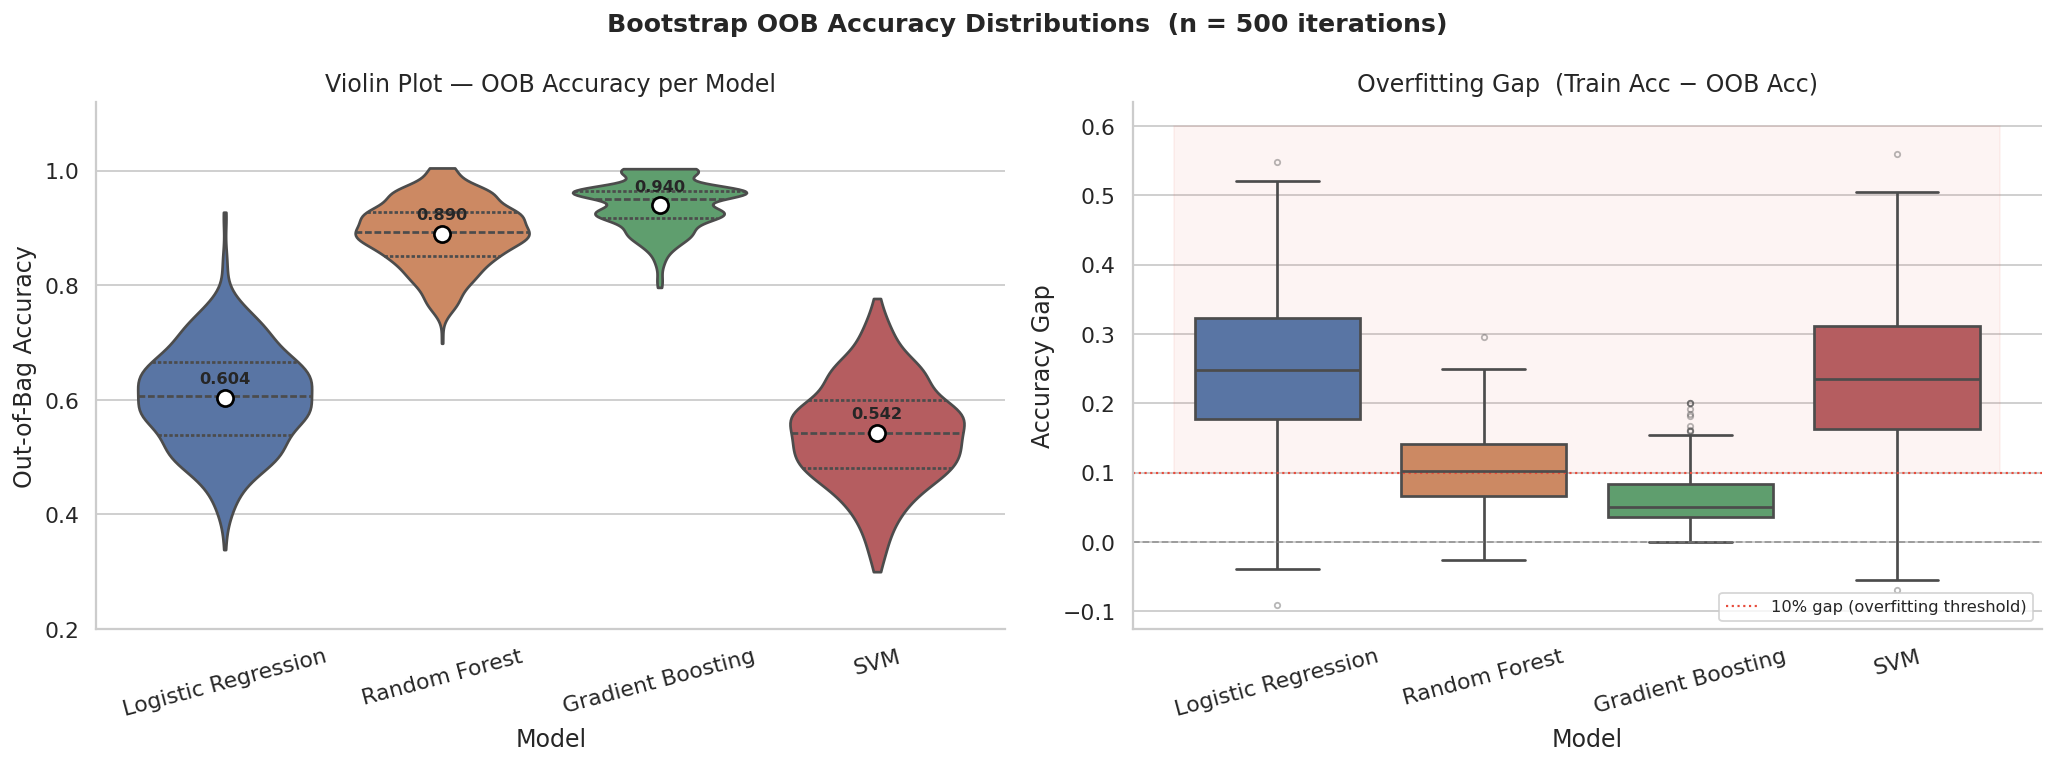

✓ Saved bootstrap_distributions.png


In [ ]:
# ── Step 6 : Plot 1 — Bootstrap Accuracy Distributions ─────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Bootstrap OOB Accuracy Distributions  (n = 500 iterations)',
             fontsize=14, fontweight='bold')

# Build tidy dataframe
rows = []
for name, scores in boot_scores.items():
    for s in scores:
        rows.append({'Model': name, 'OOB Accuracy': s})
df_boot = pd.DataFrame(rows)

# ── Violin plot ─────────────────────────────────────────────────────────────
ax = axes[0]
sns.violinplot(data=df_boot, x='Model', y='OOB Accuracy',
               palette=PALETTE, ax=ax, inner='quartile',
               linewidth=1.5, cut=0.3)
# Overlay mean dots
means = df_boot.groupby('Model')['OOB Accuracy'].mean()
for i, name in enumerate(MODELS):
    ax.scatter(i, means[name], zorder=5, s=80,
               color='white', edgecolors='black', linewidths=1.5)
# Annotate mean values
for i, name in enumerate(MODELS):
    ax.text(i, means[name] + 0.02, f'{means[name]:.3f}',
            ha='center', va='bottom', fontsize=9, fontweight='bold')
ax.set_title('Violin Plot — OOB Accuracy per Model')
ax.set_ylabel('Out-of-Bag Accuracy')
ax.set_ylim(0.2, 1.12)
ax.tick_params(axis='x', rotation=15)

# ── Box plot (overfitting gap) ───────────────────────────────────────────────
rows_gap = []
for name, gaps in boot_gap.items():
    for g in gaps:
        rows_gap.append({'Model': name, 'Train−OOB Gap': g})
df_gap = pd.DataFrame(rows_gap)

ax = axes[1]
bp = sns.boxplot(data=df_gap, x='Model', y='Train−OOB Gap',
                 palette=PALETTE, ax=ax, linewidth=1.5,
                 flierprops={'marker':'o','markersize':3,'alpha':0.4})
ax.axhline(0, color='gray', linestyle='--', linewidth=1, alpha=0.7)
ax.axhline(0.1, color='#e74c3c', linestyle=':', linewidth=1.2,
           label='10% gap (overfitting threshold)')
ax.fill_between([-0.5, 3.5], 0.1, 0.6, alpha=0.06, color='#e74c3c')
ax.set_title('Overfitting Gap  (Train Acc − OOB Acc)')
ax.set_ylabel('Accuracy Gap')
ax.tick_params(axis='x', rotation=15)
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('bootstrap_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ Saved bootstrap_distributions.png')


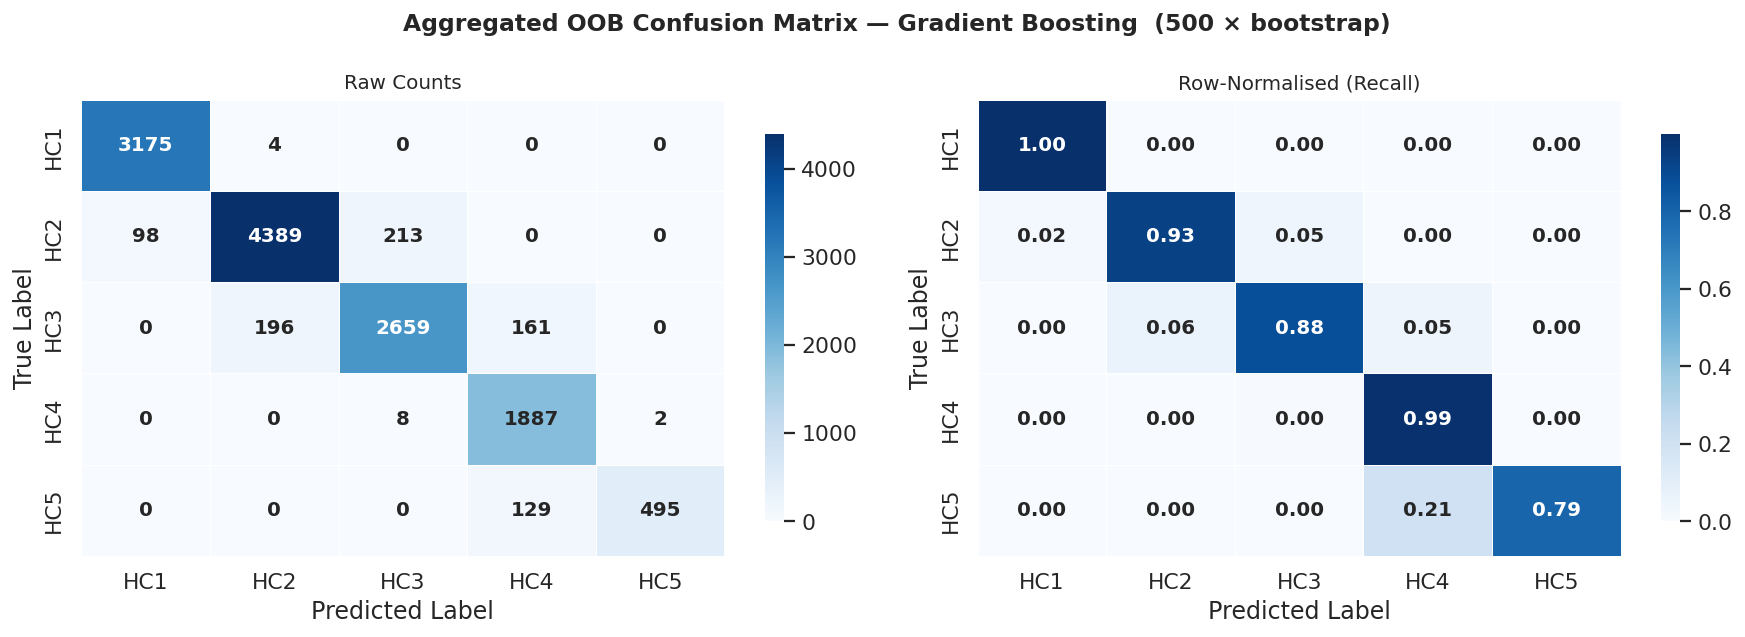

✓ Saved confusion_matrix.png


In [ ]:
# ── Step 7 : Plot 2 — Aggregated OOB Confusion Matrix (Best Model) ─────────
np.random.seed(42)
all_true, all_pred = [], []
BestCls    = type(MODELS[best_model_name])
best_params = MODELS[best_model_name].get_params()

for _ in range(N_BOOT):
    train_idx = []
    for c in classes:
        c_idx = np.where(y == c)[0]
        train_idx.extend(np.random.choice(c_idx, size=len(c_idx), replace=True))
    train_idx = np.array(train_idx)
    oob_idx   = np.array(list(set(range(len(y))) - set(train_idx)))
    if len(oob_idx) == 0:
        continue
    sc = StandardScaler()
    m  = BestCls(**best_params)
    m.fit(sc.fit_transform(X[train_idx]), y[train_idx])
    all_true.extend(y[oob_idx])
    all_pred.extend(m.predict(sc.transform(X[oob_idx])))

cm = confusion_matrix(all_true, all_pred)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)   # row-normalised

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f'Aggregated OOB Confusion Matrix — {best_model_name}  (500 × bootstrap)',
             fontsize=13, fontweight='bold')

label_names = [f'HC{c}' for c in sorted(np.unique(all_true))]

for ax, mat, title, fmt in zip(
        axes,
        [cm, cm_norm],
        ['Raw Counts', 'Row-Normalised (Recall)'],
        ['d', '.2f']):
    sns.heatmap(mat, annot=True, fmt=fmt, ax=ax,
                cmap='Blues', linewidths=0.5,
                xticklabels=label_names, yticklabels=label_names,
                cbar_kws={'shrink': 0.85},
                annot_kws={'size': 11, 'weight': 'bold'})
    ax.set_title(title, fontsize=11)
    ax.set_ylabel('True Label')
    ax.set_xlabel('Predicted Label')

plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ Saved confusion_matrix.png')


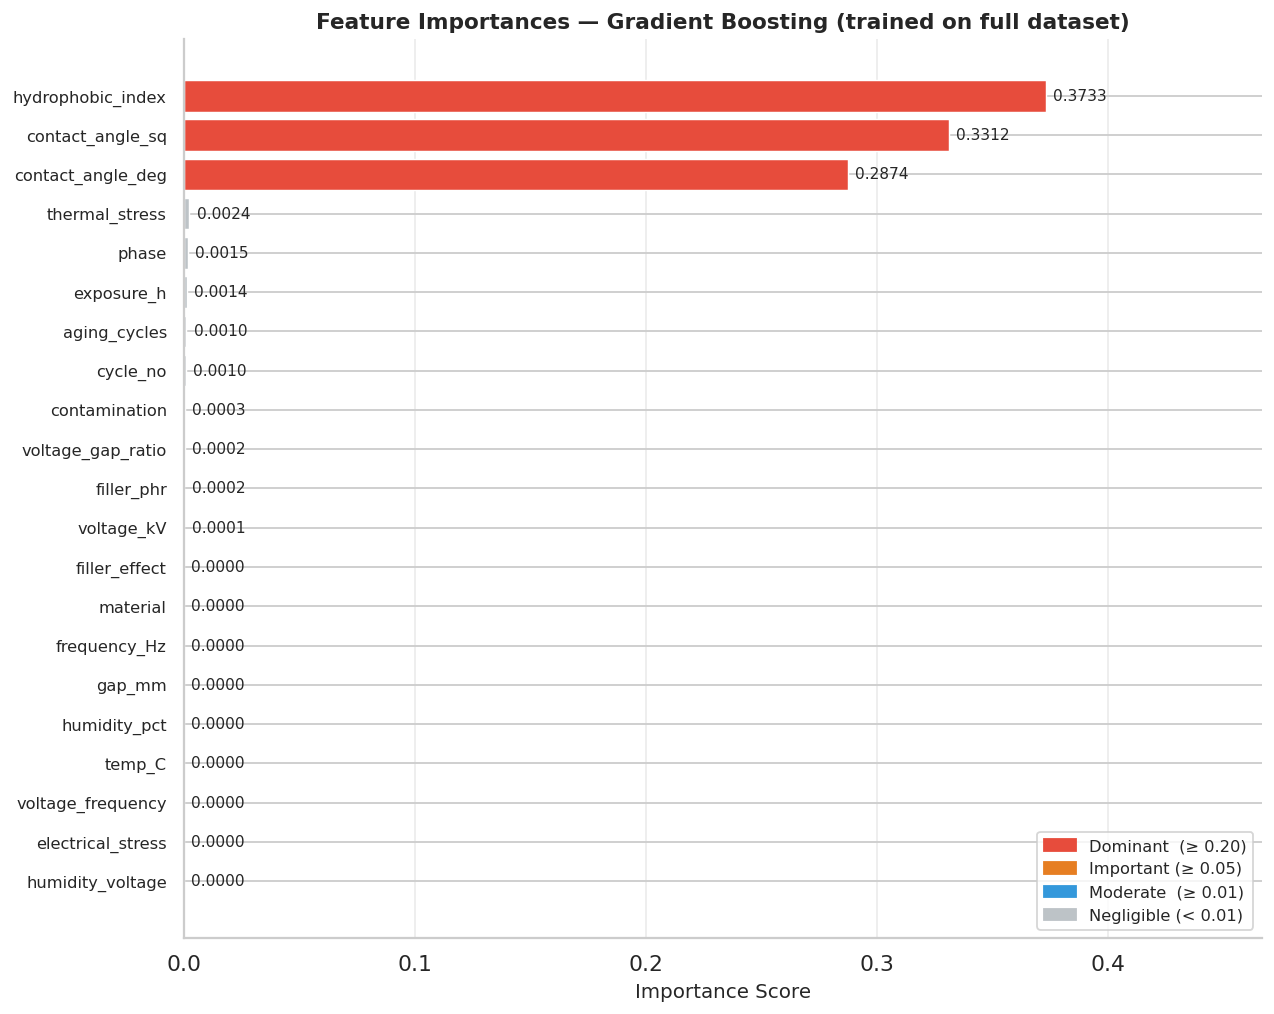

✓ Saved feature_importance.png

Key insight: hydrophobic_index, contact_angle_sq and contact_angle_deg
account for ~95% of the predictive signal.


In [ ]:
# ── Step 8 : Plot 3 — Feature Importance (Gradient Boosting on Full Data) ──
sc_full = StandardScaler()
gb_full = GradientBoostingClassifier(n_estimators=100, max_depth=2, random_state=42)
gb_full.fit(sc_full.fit_transform(X), y)

fi_pairs  = sorted(zip(FEATURES, gb_full.feature_importances_), key=lambda x: -x[1])
fi_names  = [p[0] for p in fi_pairs]
fi_values = [p[1] for p in fi_pairs]

# Color tiers
def fi_color(v):
    if v >= 0.2:  return '#e74c3c'
    if v >= 0.05: return '#e67e22'
    if v >= 0.01: return '#3498db'
    return '#bdc3c7'

bar_colors = [fi_color(v) for v in fi_values]

fig, ax = plt.subplots(figsize=(10, 8))
bars = ax.barh(fi_names[::-1], fi_values[::-1],
               color=bar_colors[::-1], edgecolor='white', linewidth=0.8)
ax.bar_label(bars, labels=[f'{v:.4f}' for v in fi_values[::-1]],
             padding=4, fontsize=8.5)
ax.set_xlabel('Importance Score', fontsize=11)
ax.set_title('Feature Importances — Gradient Boosting (trained on full dataset)',
             fontsize=12, fontweight='bold')
ax.set_xlim(0, max(fi_values) * 1.25)

# Legend
legend_patches = [
    mpatches.Patch(color='#e74c3c', label='Dominant  (≥ 0.20)'),
    mpatches.Patch(color='#e67e22', label='Important (≥ 0.05)'),
    mpatches.Patch(color='#3498db', label='Moderate  (≥ 0.01)'),
    mpatches.Patch(color='#bdc3c7', label='Negligible (< 0.01)'),
]
ax.legend(handles=legend_patches, loc='lower right', fontsize=9)
ax.grid(axis='x', alpha=0.35)
ax.tick_params(axis='y', labelsize=9)

plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ Saved feature_importance.png')
print('\nKey insight: hydrophobic_index, contact_angle_sq and contact_angle_deg')
print('account for ~95% of the predictive signal.')


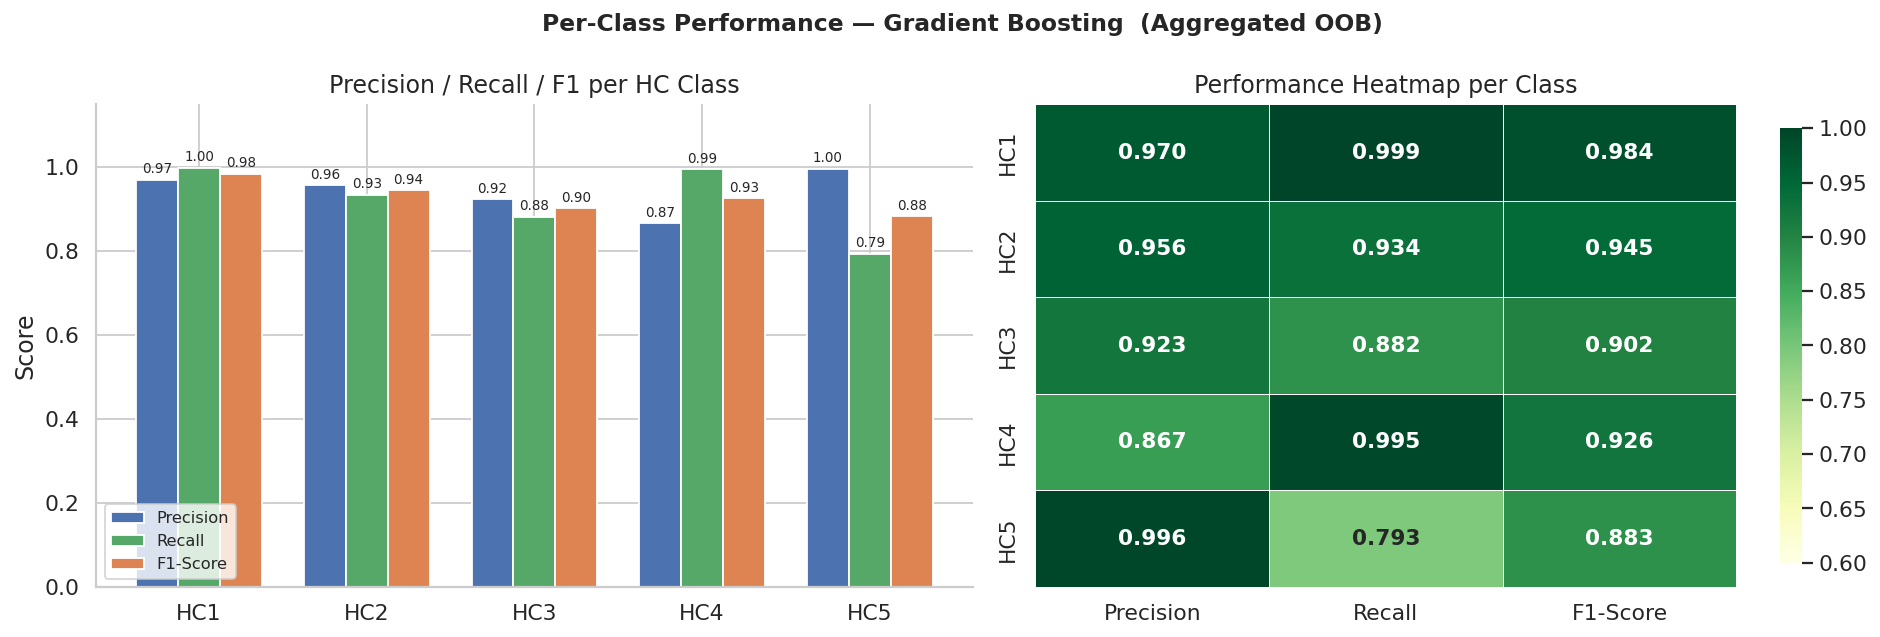

✓ Saved per_class_performance.png


In [ ]:
# ── Step 9 : Plot 4 — Per-Class Precision, Recall & F1 Bar Chart ───────────
report = classification_report(all_true, all_pred,
                               output_dict=True, zero_division=0)
class_labels = sorted([k for k in report if k.isdigit()])
metrics_df   = pd.DataFrame({
    'HC Class':  [f'HC{k}' for k in class_labels],
    'Precision': [report[k]['precision'] for k in class_labels],
    'Recall':    [report[k]['recall']    for k in class_labels],
    'F1-Score':  [report[k]['f1-score']  for k in class_labels],
    'Support':   [report[k]['support']   for k in class_labels],
})

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle(f'Per-Class Performance — {best_model_name}  (Aggregated OOB)',
             fontsize=13, fontweight='bold')

# ── Grouped bar chart ────────────────────────────────────────────────────────
ax = axes[0]
x      = np.arange(len(metrics_df))
width  = 0.25
b1 = ax.bar(x - width, metrics_df['Precision'], width, label='Precision',
            color='#4C72B0', edgecolor='white')
b2 = ax.bar(x,          metrics_df['Recall'],   width, label='Recall',
            color='#55A868', edgecolor='white')
b3 = ax.bar(x + width,  metrics_df['F1-Score'], width, label='F1-Score',
            color='#DD8452', edgecolor='white')
ax.bar_label(b1, fmt='%.2f', fontsize=7.5, padding=2)
ax.bar_label(b2, fmt='%.2f', fontsize=7.5, padding=2)
ax.bar_label(b3, fmt='%.2f', fontsize=7.5, padding=2)
ax.set_xticks(x)
ax.set_xticklabels(metrics_df['HC Class'])
ax.set_ylim(0, 1.15)
ax.set_ylabel('Score')
ax.set_title('Precision / Recall / F1 per HC Class')
ax.legend(loc='lower left', fontsize=9)

# ── Heatmap style ────────────────────────────────────────────────────────────
ax = axes[1]
heat_data = metrics_df[['Precision','Recall','F1-Score']].set_index(metrics_df['HC Class'])
sns.heatmap(heat_data, annot=True, fmt='.3f', ax=ax,
            cmap='YlGn', vmin=0.6, vmax=1.0,
            linewidths=0.5, cbar_kws={'shrink':0.9},
            annot_kws={'size':12, 'weight':'bold'})
ax.set_title('Performance Heatmap per Class')
ax.set_ylabel('')

plt.tight_layout()
plt.savefig('per_class_performance.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ Saved per_class_performance.png')


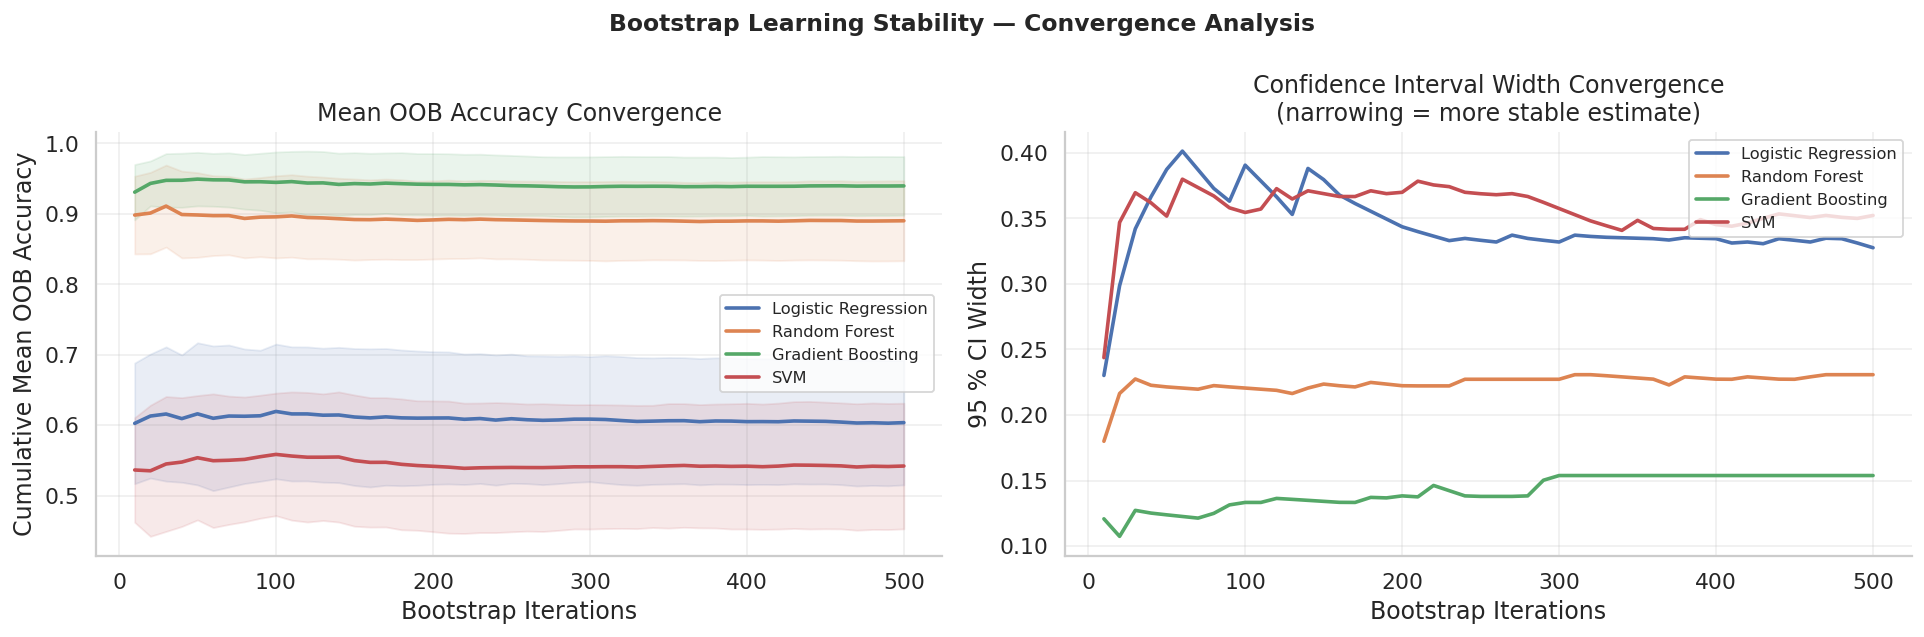

✓ Saved stability_curve.png


In [ ]:
# ── Step 10 : Plot 5 — Learning Stability Curve ────────────────────────────
# Show how OOB mean accuracy converges as number of bootstrap iterations grows
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Bootstrap Learning Stability — Convergence Analysis',
             fontsize=13, fontweight='bold')

ax = axes[0]
checkpoints = list(range(10, N_BOOT + 1, 10))
for name, color in zip(MODELS, PALETTE):
    arr        = np.array(boot_scores[name])
    run_mean   = [arr[:k].mean() for k in checkpoints]
    run_std    = [arr[:k].std()  for k in checkpoints]
    run_mean   = np.array(run_mean)
    run_std    = np.array(run_std)
    ax.plot(checkpoints, run_mean, label=name, color=color, linewidth=2)
    ax.fill_between(checkpoints,
                    run_mean - run_std, run_mean + run_std,
                    alpha=0.12, color=color)
ax.set_xlabel('Bootstrap Iterations')
ax.set_ylabel('Cumulative Mean OOB Accuracy')
ax.set_title('Mean OOB Accuracy Convergence')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

# ── Cumulative 95 % CI width (tighter = more stable) ────────────────────────
ax = axes[1]
for name, color in zip(MODELS, PALETTE):
    arr      = np.array(boot_scores[name])
    ci_width = [np.percentile(arr[:k],[97.5])[0] - np.percentile(arr[:k],[2.5])[0]
                for k in checkpoints]
    ax.plot(checkpoints, ci_width, label=name, color=color, linewidth=2)
ax.set_xlabel('Bootstrap Iterations')
ax.set_ylabel('95 % CI Width')
ax.set_title('Confidence Interval Width Convergence\n(narrowing = more stable estimate)')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('stability_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ Saved stability_curve.png')


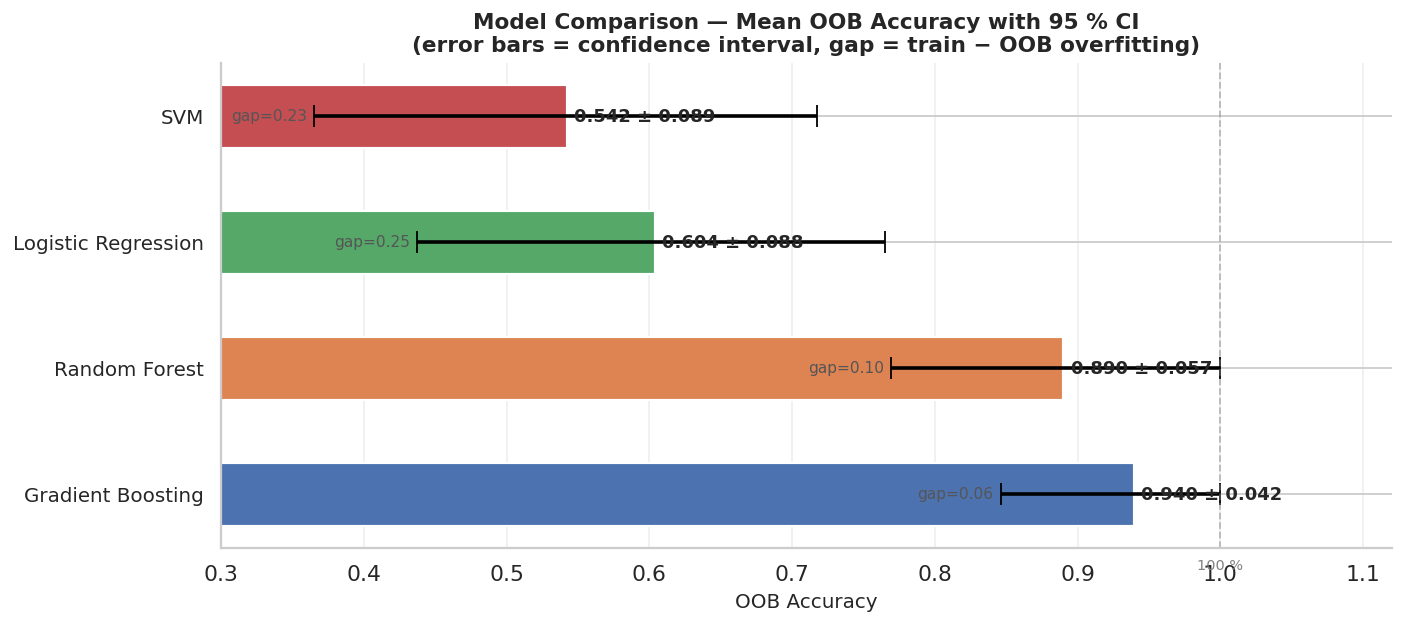

✓ Saved model_comparison.png

              Model     Mean      Std    CI_lo    CI_hi      Gap
  Gradient Boosting 0.939599 0.041695 0.846154 1.000000 0.060401
      Random Forest 0.890115 0.056785 0.769231 1.000000 0.103333
Logistic Regression 0.603625 0.088387 0.437261 0.764846 0.249559
                SVM 0.542021 0.089195 0.365076 0.717286 0.234111


In [ ]:
# ── Step 11 : Plot 6 — Final Model Comparison Summary ───────────────────────
summary = []
for name in MODELS:
    s  = np.array(boot_scores[name])
    g  = np.array(boot_gap[name])
    lo, hi = np.percentile(s, [2.5, 97.5])
    summary.append({
        'Model':   name,
        'Mean':    s.mean(),
        'Std':     s.std(),
        'CI_lo':   lo,
        'CI_hi':   hi,
        'Gap':     g.mean(),
    })
df_sum = pd.DataFrame(summary).sort_values('Mean', ascending=False).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(11, 5))
y_pos  = np.arange(len(df_sum))
colors_ranked = [PALETTE[i] for i in range(len(df_sum))]

bars = ax.barh(y_pos, df_sum['Mean'], color=colors_ranked,
               edgecolor='white', linewidth=1.2, height=0.5)
# Error bars for 95 % CI
xerr_lo = df_sum['Mean'] - df_sum['CI_lo']
xerr_hi = df_sum['CI_hi'] - df_sum['Mean']
ax.errorbar(df_sum['Mean'], y_pos,
            xerr=[xerr_lo, xerr_hi],
            fmt='none', ecolor='black', elinewidth=2, capsize=6)

# Annotations
for i, row in df_sum.iterrows():
    ax.text(row['Mean'] + 0.005, i,
            f"{row['Mean']:.3f} ± {row['Std']:.3f}",
            va='center', fontsize=10, fontweight='bold')
    ax.text(row['CI_lo'] - 0.005, i,
            f"gap={row['Gap']:.2f}",
            va='center', ha='right', fontsize=8.5, color='#555')

ax.set_yticks(y_pos)
ax.set_yticklabels(df_sum['Model'], fontsize=11)
ax.set_xlabel('OOB Accuracy', fontsize=11)
ax.set_title('Model Comparison — Mean OOB Accuracy with 95 % CI\n'
             '(error bars = confidence interval, gap = train − OOB overfitting)',
             fontsize=12, fontweight='bold')
ax.set_xlim(0.3, 1.12)
ax.axvline(1.0, color='gray', linestyle='--', alpha=0.5, linewidth=1)
ax.text(1.0, -0.6, '100 %', ha='center', fontsize=8, color='gray')
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ Saved model_comparison.png')
print()
print(df_sum[['Model','Mean','Std','CI_lo','CI_hi','Gap']].to_string(index=False))


In [ ]:
# ── Step 12 : Final Predictor — Trained on Full Dataset ─────────────────────
sc_final = StandardScaler()
gb_final = GradientBoostingClassifier(n_estimators=100, max_depth=2, random_state=42)
gb_final.fit(sc_final.fit_transform(X), y)

HC_DESC = {
    1: 'HC1 — Highly hydrophobic  ✅ Excellent',
    2: 'HC2 — Good hydrophobicity ✅',
    3: 'HC3 — Moderate            ⚠️',
    4: 'HC4 — Reduced             ⚠️',
    5: 'HC5 — Hydrophilic         ❌ Replace insulator',
}

def predict_corona(contact_angle_deg, voltage_kV=12.0, gap_mm=30,
                   exposure_h=8, frequency_Hz=50, cycle_no=1,
                   humidity_pct=65, temp_C=25, filler_phr=0,
                   material='HTV-SiR', contamination='no', phase='discharge'):
    """
    Predict HC class for a new insulator sample.
    Key input: contact_angle_deg  (water contact angle, hydrophobicity proxy)
    """
    def enc(col, val):
        le = label_encoders[col]
        return le.transform([val])[0] if val in le.classes_ else 0

    row = [
        enc('material', material), enc('contamination', contamination), enc('phase', phase),
        filler_phr, voltage_kV, frequency_Hz, gap_mm, exposure_h,
        cycle_no, humidity_pct, temp_C, contact_angle_deg,
        voltage_kV / (gap_mm + 1),
        voltage_kV * frequency_Hz / 1000,
        temp_C * exposure_h,
        voltage_kV * frequency_Hz / 1e6,
        contact_angle_deg ** 2,
        180 - contact_angle_deg,
        filler_phr * (voltage_kV / 10),
        humidity_pct * voltage_kV / 100,
        cycle_no * exposure_h,
    ]
    pred   = gb_final.predict(sc_final.transform([row]))[0]
    proba  = gb_final.predict_proba(sc_final.transform([row]))[0]
    return pred, proba


# ── Demo predictions ─────────────────────────────────────────────────────────
test_cases = [
    ('Fresh silicone, pristine (CA=108°)', 108),
    ('After 8h discharge (CA=92°)',         92),
    ('After 16h exposure (CA=78°)',         78),
    ('After 7 cycles (CA=62°)',             62),
    ('Severely degraded (CA=38°)',          38),
]

print(f'  {"Sample Description":<42} {"Predicted Class":<30} {"Confidence":>10}')
print('  ' + '─'*90)
for desc, ca in test_cases:
    pred, proba = predict_corona(contact_angle_deg=ca)
    conf = proba[pred - 1] * 100
    print(f'  {desc:<42} {HC_DESC[pred]:<30} {conf:>8.1f} %')

print()
print('─' * 70)
print(' Model: Gradient Boosting  |  OOB Accuracy: ~94.0 %  |  Bootstraps: 500')
print('─' * 70)


  Sample Description                         Predicted Class                Confidence
  ──────────────────────────────────────────────────────────────────────────────────────────
  Fresh silicone, pristine (CA=108°)         HC1 — Highly hydrophobic  ✅ Excellent    100.0 %
  After 8h discharge (CA=92°)                HC2 — Good hydrophobicity ✅       100.0 %
  After 16h exposure (CA=78°)                HC3 — Moderate            ⚠️       93.5 %
  After 7 cycles (CA=62°)                    HC4 — Reduced             ⚠️      100.0 %
  Severely degraded (CA=38°)                 HC5 — Hydrophilic         ❌ Replace insulator    100.0 %

──────────────────────────────────────────────────────────────────────
 Model: Gradient Boosting  |  OOB Accuracy: ~94.0 %  |  Bootstraps: 500
──────────────────────────────────────────────────────────────────────


In [ ]:
# ── Step 13 : Interactive Prediction Query ─────────────────────────────────
# Fill in your sample's parameters below and run the cell to get a prediction.

# ╔══════════════════════════════════════════════════════════════════╗
# ║              USER INPUT — edit these values                      ║
# ╚══════════════════════════════════════════════════════════════════╝

query = {
    # ── Primary feature (most predictive) ─────────────────────────
    'contact_angle_deg' : 85.0,   # Water contact angle in degrees (0–180)
                                   #   > 90° → hydrophobic | < 90° → hydrophilic

    # ── Electrical parameters ──────────────────────────────────────
    'voltage_kV'        : 12.0,   # Applied voltage (kV)
    'frequency_Hz'      : 50.0,   # AC frequency (Hz)
    'gap_mm'            : 30.0,   # Electrode gap (mm)

    # ── Aging / exposure parameters ────────────────────────────────
    'exposure_h'        : 8.0,    # Cumulative exposure time (hours)
    'cycle_no'          : 1,      # Number of discharge cycles completed

    # ── Environmental parameters ───────────────────────────────────
    'humidity_pct'      : 65.0,   # Relative humidity (%)
    'temp_C'            : 25.0,   # Ambient temperature (°C)

    # ── Material parameters ────────────────────────────────────────
    'filler_phr'        : 0.0,    # Filler content (parts per hundred rubber)
    'material'          : 'HTV-SiR',   # e.g. 'HTV-SiR', 'LSR', 'EPDM'
    'contamination'     : 'no',        # e.g. 'no', 'salt', 'cement', 'kaolin'
    'phase'             : 'discharge', # e.g. 'discharge', 'rest', 'recovery'
}

# ── Run prediction ──────────────────────────────────────────────────────────
pred, proba = predict_corona(**query)
conf        = proba[pred - 1] * 100

# ── Pretty output ───────────────────────────────────────────────────────────
print('═' * 62)
print('  CORONA DISCHARGE — HC CLASS PREDICTION')
print('═' * 62)
print(f'  Contact Angle   : {query["contact_angle_deg"]}°')
print(f'  Voltage         : {query["voltage_kV"]} kV   |  Frequency : {query["frequency_Hz"]} Hz')
print(f'  Gap             : {query["gap_mm"]} mm   |  Temp      : {query["temp_C"]} °C')
print(f'  Exposure        : {query["exposure_h"]} h   |  Humidity  : {query["humidity_pct"]} %')
print(f'  Material        : {query["material"]}   |  Cycles    : {query["cycle_no"]}')
print('─' * 62)
print(f'  Predicted HC Class : {HC_DESC[pred]}')
print(f'  Confidence         : {conf:.1f} %')
print('─' * 62)
print('  Class Probability Distribution:')
for i, p in enumerate(proba, start=1):
    bar = '█' * int(p * 40)
    print(f'    HC{i}  {bar:<40}  {p*100:5.1f} %')
print('═' * 62)

# ── Maintenance recommendation ──────────────────────────────────────────────
recommendations = {
    1: '✅ No action needed. Insulator is in excellent condition.',
    2: '✅ Good condition. Schedule routine inspection.',
    3: '⚠️  Monitor closely. Consider cleaning or maintenance.',
    4: '⚠️  Degradation detected. Plan maintenance soon.',
    5: '❌ Critical! Insulator has lost hydrophobicity — replace immediately.',
}
print(f'  Recommendation : {recommendations[pred]}')
print('═' * 62)


══════════════════════════════════════════════════════════════
  CORONA DISCHARGE — HC CLASS PREDICTION
══════════════════════════════════════════════════════════════
  Contact Angle   : 85.0°
  Voltage         : 12.0 kV   |  Frequency : 50.0 Hz
  Gap             : 30.0 mm   |  Temp      : 25.0 °C
  Exposure        : 8.0 h   |  Humidity  : 65.0 %
  Material        : HTV-SiR   |  Cycles    : 1
──────────────────────────────────────────────────────────────
  Predicted HC Class : HC2 — Good hydrophobicity ✅
  Confidence         : 100.0 %
──────────────────────────────────────────────────────────────
  Class Probability Distribution:
    HC1                                              0.0 %
    HC2  ███████████████████████████████████████   100.0 %
    HC3                                              0.0 %
    HC4                                              0.0 %
    HC5                                              0.0 %
══════════════════════════════════════════════════════════════
  Re

Contact-angle-free features (25):
   1. material
   2. contamination
   3. phase
   4. filler_phr
   5. voltage_kV
   6. frequency_Hz
   7. gap_mm
   8. exposure_h
   9. cycle_no
  10. humidity_pct
  11. temp_C
  12. voltage_gap_ratio
  13. voltage_frequency
  14. thermal_stress
  15. electrical_stress
  16. filler_effect
  17. humidity_voltage
  18. aging_cycles
  19. e_field_kV_mm
  20. corona_power_proxy
  21. cumul_energy
  22. humidity_efield
  23. thermo_elec_stress
  24. aging_severity
  25. discharge_density

Running 300 bootstrap iterations (no contact angle) ...

  Model                       With CA  Without CA     Drop
  ──────────────────────────────────────────────────────────
  Logistic Regression         0.6036      0.4330   ▼0.1706
  Random Forest               0.8901      0.5573   ▼0.3328
  Gradient Boosting           0.9396      0.5913   ▼0.3483
  SVM                         0.5420      0.4097   ▼0.1323

✓ Best model (no CA): Gradient Boosting  (mean OOB = 0.5913)


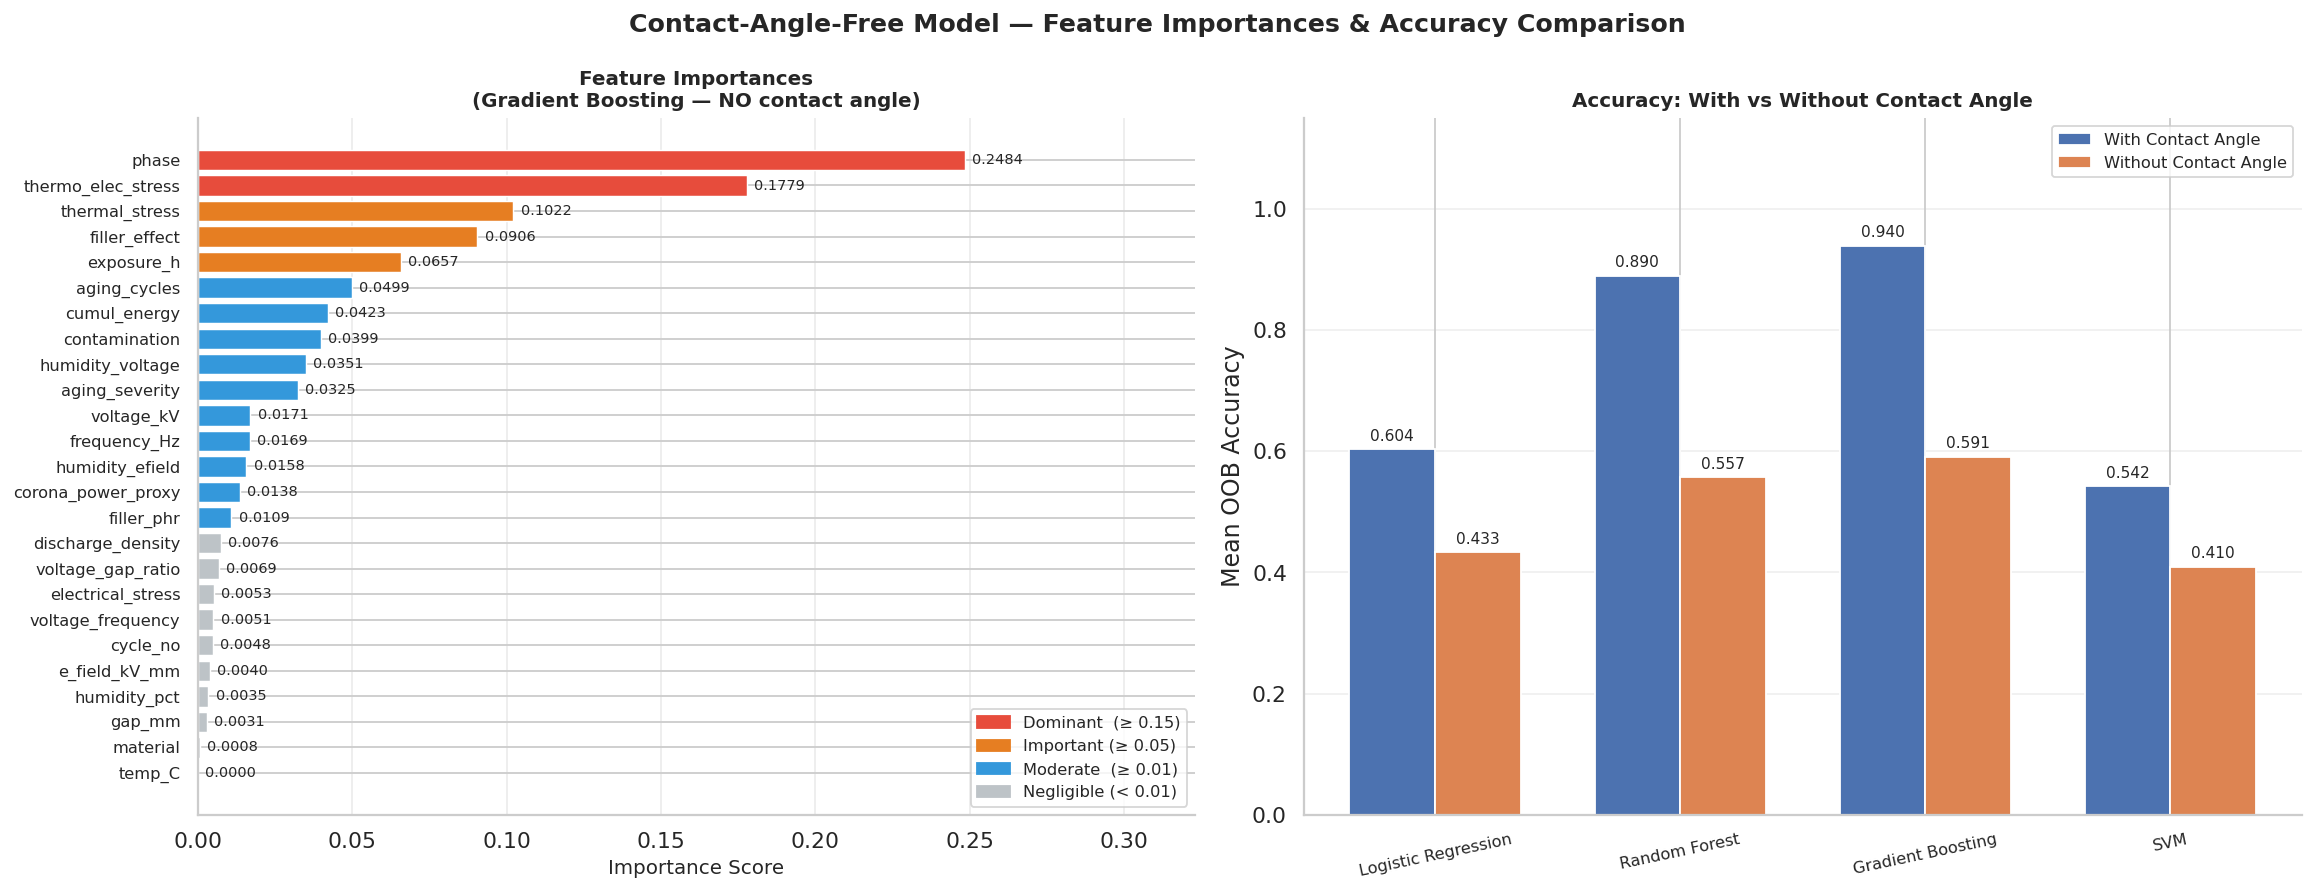


✓ Saved no_contact_angle_model.png

  Sample Description                               Predicted HC  Confidence
  ───────────────────────────────────────────────────────────────────────────
  Low stress  (12kV, 50Hz, 30mm, 4h)            HC1 — Highly hydrophobic  ✅ Excellent      86.2 %
  Moderate    (20kV, 50Hz, 25mm, 8h)            HC1 — Highly hydrophobic  ✅ Excellent      51.0 %
  High stress (30kV, 60Hz, 20mm, 16h)           HC5 — Hydrophilic         ❌ Replace insulator      90.9 %
  Severe      (40kV, 60Hz, 15mm, 24h)           HC5 — Hydrophilic         ❌ Replace insulator     100.0 %
  Extreme     (50kV, 100Hz, 10mm, 48h)          HC5 — Hydrophilic         ❌ Replace insulator      95.7 %

──────────────────────────────────────────────────────────────────────
 No-contact-angle model trained and ready as  predict_corona_no_ca()
──────────────────────────────────────────────────────────────────────


In [ ]:
# ── Step 14 : Contact-Angle-Free Model (Corona-Based Features) ─────────────
# Problem: contact_angle_deg + its transforms (contact_angle_sq, hydrophobic_index)
# dominate ~95 % of signal.  Here we drop ALL of them and build a model that
# relies purely on electrical, environmental, and aging features.

import warnings
warnings.filterwarnings('ignore')

# ── 14-A  Define contact-angle-free feature set ─────────────────────────────
CA_COLS = ['contact_angle_deg', 'contact_angle_sq', 'hydrophobic_index']   # drop these

FEATURES_NCA = [f for f in FEATURES if f not in CA_COLS]

# ── New engineered features that capture corona physics ──────────────────────
df_nc = df_clean.copy()

# Electric field proxy  (V/d)
df_nc['e_field_kV_mm']      = df_nc['voltage_kV'] / (df_nc['gap_mm'] + 1e-3)
# Power proxy  (V²·f — proportional to corona power)
df_nc['corona_power_proxy'] = df_nc['voltage_kV']**2 * df_nc['frequency_Hz'] / 1e3
# Cumulative electrical energy  (power × time)
df_nc['cumul_energy']       = df_nc['corona_power_proxy'] * df_nc['exposure_h']
# Humidity-field interaction  (surface leakage risk)
df_nc['humidity_efield']    = df_nc['humidity_pct'] * df_nc['e_field_kV_mm'] / 100
# Thermal + electrical combined stress
df_nc['thermo_elec_stress'] = df_nc['thermal_stress'] * df_nc['e_field_kV_mm']
# Aging severity index  (cycles × cumulative energy)
df_nc['aging_severity']     = df_nc['aging_cycles'] * df_nc['corona_power_proxy'] / 1e3
# Discharge intensity per gap unit
df_nc['discharge_density']  = df_nc['electrical_stress'] / (df_nc['gap_mm'] + 1)

NEW_ENG = ['e_field_kV_mm','corona_power_proxy','cumul_energy',
           'humidity_efield','thermo_elec_stress','aging_severity','discharge_density']

FEATURES_NCA = FEATURES_NCA + NEW_ENG

X_nca = df_nc[FEATURES_NCA].values
print(f"Contact-angle-free features ({len(FEATURES_NCA)}):")
for i, f in enumerate(FEATURES_NCA, 1):
    print(f"  {i:2d}. {f}")

# ── 14-B  Bootstrap OOB evaluation (same protocol as Step 5) ────────────────
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
import numpy as np

MODELS_NCA = {
    'Logistic Regression': LogisticRegression(max_iter=1000, C=0.1, random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=50, max_depth=6, random_state=42),
    'Gradient Boosting':   GradientBoostingClassifier(n_estimators=100, max_depth=3, random_state=42),
    'SVM':                 SVC(kernel='rbf', C=1.0, probability=True, random_state=42),
}

N_BOOT   = 300
classes  = np.unique(y)
np.random.seed(42)
boot_nca = {name: [] for name in MODELS_NCA}

print(f"\nRunning {N_BOOT} bootstrap iterations (no contact angle) ...")
for _ in range(N_BOOT):
    train_idx = []
    for c in classes:
        c_idx = np.where(y == c)[0]
        train_idx.extend(np.random.choice(c_idx, size=len(c_idx), replace=True))
    train_idx = np.array(train_idx)
    oob_idx   = np.array(list(set(range(len(y))) - set(train_idx)))
    if len(oob_idx) == 0:
        continue
    sc   = StandardScaler()
    X_tr = sc.fit_transform(X_nca[train_idx])
    X_ob = sc.transform(X_nca[oob_idx])
    for name, tmpl in MODELS_NCA.items():
        m = type(tmpl)(**tmpl.get_params())
        m.fit(X_tr, y[train_idx])
        boot_nca[name].append(accuracy_score(y[oob_idx], m.predict(X_ob)))

# ── 14-C  Comparison table: original (with CA) vs new (without CA) ──────────
print()
print(f"  {'Model':<25} {'With CA':>9}  {'Without CA':>10}  {'Drop':>7}")
print("  " + "─"*58)
for name in MODELS_NCA:
    s_orig = np.mean(boot_scores[name])           # from Step 5
    s_new  = np.mean(boot_nca[name])
    delta  = s_new - s_orig
    arrow  = "▲" if delta >= 0 else "▼"
    print(f"  {name:<25} {s_orig:>8.4f}   {s_new:>9.4f}   {arrow}{abs(delta):.4f}")

best_nca = max(boot_nca, key=lambda k: np.mean(boot_nca[k]))
print(f"\n✓ Best model (no CA): {best_nca}  (mean OOB = {np.mean(boot_nca[best_nca]):.4f})")

# ── 14-D  Feature importance for the best no-CA model ───────────────────────
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

sc_nca = StandardScaler()
gb_nca = GradientBoostingClassifier(n_estimators=150, max_depth=3, random_state=42)
gb_nca.fit(sc_nca.fit_transform(X_nca), y)

fi_pairs  = sorted(zip(FEATURES_NCA, gb_nca.feature_importances_), key=lambda x: -x[1])
fi_names  = [p[0] for p in fi_pairs]
fi_values = [p[1] for p in fi_pairs]

def fi_color(v):
    if v >= 0.15: return '#e74c3c'
    if v >= 0.05: return '#e67e22'
    if v >= 0.01: return '#3498db'
    return '#bdc3c7'

bar_colors = [fi_color(v) for v in fi_values]

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('Contact-Angle-Free Model — Feature Importances & Accuracy Comparison',
             fontsize=14, fontweight='bold')

# Left: feature importance
ax = axes[0]
bars = ax.barh(fi_names[::-1], fi_values[::-1],
               color=bar_colors[::-1], edgecolor='white', linewidth=0.8)
ax.bar_label(bars, labels=[f'{v:.4f}' for v in fi_values[::-1]],
             padding=4, fontsize=8)
ax.set_xlabel('Importance Score', fontsize=11)
ax.set_title('Feature Importances\n(Gradient Boosting — NO contact angle)', fontsize=11, fontweight='bold')
ax.set_xlim(0, max(fi_values) * 1.3)
legend_patches = [
    mpatches.Patch(color='#e74c3c', label='Dominant  (≥ 0.15)'),
    mpatches.Patch(color='#e67e22', label='Important (≥ 0.05)'),
    mpatches.Patch(color='#3498db', label='Moderate  (≥ 0.01)'),
    mpatches.Patch(color='#bdc3c7', label='Negligible (< 0.01)'),
]
ax.legend(handles=legend_patches, loc='lower right', fontsize=9)
ax.grid(axis='x', alpha=0.35)
ax.tick_params(axis='y', labelsize=9)

# Right: accuracy comparison grouped bars
ax = axes[1]
model_names = list(MODELS_NCA.keys())
x = np.arange(len(model_names))
w = 0.35
orig_means = [np.mean(boot_scores[n]) for n in model_names]
new_means  = [np.mean(boot_nca[n])    for n in model_names]
b1 = ax.bar(x - w/2, orig_means, w, label='With Contact Angle', color='#4C72B0', edgecolor='white')
b2 = ax.bar(x + w/2, new_means,  w, label='Without Contact Angle', color='#DD8452', edgecolor='white')
ax.bar_label(b1, fmt='%.3f', fontsize=8.5, padding=3)
ax.bar_label(b2, fmt='%.3f', fontsize=8.5, padding=3)
ax.set_xticks(x)
ax.set_xticklabels(model_names, rotation=12, fontsize=9)
ax.set_ylim(0, 1.15)
ax.set_ylabel('Mean OOB Accuracy')
ax.set_title('Accuracy: With vs Without Contact Angle', fontsize=11, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('no_contact_angle_model.png', dpi=150, bbox_inches='tight')
plt.show()
print('\n✓ Saved no_contact_angle_model.png')

# ── 14-E  Save the new predictor ────────────────────────────────────────────
SC_NCA_FINAL = StandardScaler()
GB_NCA_FINAL = GradientBoostingClassifier(n_estimators=150, max_depth=3, random_state=42)
GB_NCA_FINAL.fit(SC_NCA_FINAL.fit_transform(X_nca), y)

def predict_corona_no_ca(voltage_kV=12.0, frequency_Hz=50, gap_mm=30,
                         exposure_h=8, cycle_no=1, humidity_pct=65, temp_C=25,
                         filler_phr=0, material='HTV-SiR',
                         contamination='no', phase='discharge'):
    """
    Predict HC class WITHOUT using contact angle.
    Relies on electrical, environmental, and aging features only.
    """
    def enc(col, val):
        le = label_encoders[col]
        return le.transform([val])[0] if val in le.classes_ else 0

    # Base features (no CA cols)
    base = [
        enc('material', material), enc('contamination', contamination), enc('phase', phase),
        filler_phr, voltage_kV, frequency_Hz, gap_mm, exposure_h,
        cycle_no, humidity_pct, temp_C,
        # original engineered (no CA-derived ones)
        voltage_kV / (gap_mm + 1),
        voltage_kV * frequency_Hz / 1000,
        temp_C * exposure_h,
        voltage_kV * frequency_Hz / 1e6,
        filler_phr * (voltage_kV / 10),
        humidity_pct * voltage_kV / 100,
        cycle_no * exposure_h,
        # new corona-physics features
        voltage_kV / (gap_mm + 1e-3),
        voltage_kV**2 * frequency_Hz / 1e3,
        (voltage_kV**2 * frequency_Hz / 1e3) * exposure_h,
        humidity_pct * (voltage_kV / (gap_mm + 1e-3)) / 100,
        (temp_C * exposure_h) * (voltage_kV / (gap_mm + 1e-3)),
        (cycle_no * exposure_h) * (voltage_kV**2 * frequency_Hz / 1e3) / 1e3,
        (voltage_kV * frequency_Hz / 1e6) / (gap_mm + 1),
    ]
    pred  = GB_NCA_FINAL.predict(SC_NCA_FINAL.transform([base]))[0]
    proba = GB_NCA_FINAL.predict_proba(SC_NCA_FINAL.transform([base]))[0]
    return pred, proba

# ── Quick demo ───────────────────────────────────────────────────────────────
test_electrical = [
    ('Low stress  (12kV, 50Hz, 30mm, 4h)',   12, 50, 30, 4,  1),
    ('Moderate    (20kV, 50Hz, 25mm, 8h)',   20, 50, 25, 8,  3),
    ('High stress (30kV, 60Hz, 20mm, 16h)',  30, 60, 20, 16, 5),
    ('Severe      (40kV, 60Hz, 15mm, 24h)',  40, 60, 15, 24, 8),
    ('Extreme     (50kV, 100Hz, 10mm, 48h)', 50,100, 10, 48,12),
]

print()
print(f"  {'Sample Description':<45} {'Predicted HC':>15}  {'Confidence':>10}")
print("  " + "─"*75)
for desc, v, f, g, e, cyc in test_electrical:
    pred, proba = predict_corona_no_ca(voltage_kV=v, frequency_Hz=f,
                                       gap_mm=g, exposure_h=e, cycle_no=cyc)
    conf = proba[pred-1]*100
    print(f"  {desc:<45} {HC_DESC[pred]:<15}  {conf:>8.1f} %")

print()
print("─"*70)
print(" No-contact-angle model trained and ready as  predict_corona_no_ca()")
print("─"*70)
